In [1]:
from dotenv import load_dotenv, find_dotenv

assert load_dotenv(find_dotenv(usecwd=False)), "The .env file was not loaded."

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import torch

from drn import Constant, GLM, CANN, MDN, DDR, DRN, split_data, preprocess_data

from analysis_utils import rank_models_per_seed, calculate_metrics

/Users/ericdong/opt/anaconda3/envs/project1_runpod/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parallel tools
from joblib import Parallel, delayed
import os
# Keep per-process math libs to a single thread by default
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
torch.set_num_threads(1)

VERSION = "ds3"

# Detect accelerator and choose worker count
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
MAX_WORKERS = min(20, (os.cpu_count() or 1)) if accelerator == "cpu" else 1
print(f"Using {accelerator}; max parallel workers = {MAX_WORKERS}")

Using cpu; max parallel workers = 8


In [3]:
DATA_DIR = Path("data/interim/real")
features = pd.read_csv(
    DATA_DIR / "features.csv", na_values=["NA"], keep_default_na=False
)
target = pd.read_csv(DATA_DIR / "target.csv")


TABLE_DIR = Path("tables/splitting-test")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = Path("plots/splitting-test")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Training

In [4]:
cat_features = [
    "HasKmLimit",
    "Garage",
    "Gender",
    "MariStat",
    "SocioCateg",
    "VehBody",
    "VehEngine",
    "VehEnergy",
    "VehClass",
    "VehPrice",
    "VehUsage",
]

num_features = [feature for feature in features.columns if feature not in cat_features]

In [5]:
np.random.seed(31052025)

NUM_RANDOM_SPLITS = 100
split_seeds = [int(s) for s in np.random.randint(0, 2**32 - 1, size=NUM_RANDOM_SPLITS)]

shared_fit_kwargs = {
    "batch_size": 128,
    "accelerator": accelerator,
    "epochs": 1000,
    "patience": 50,
    "enable_progress_bar": False,
    "enable_model_summary": False,
}

distribution = "gamma"
learning_rate = 1e-3
hidden_size = 256
dropout_rate = 0.2
num_hidden_layers = 3
num_components = 5
proportion = 0.4
min_obs = 5
kl_alpha = 5e-3#1e-2
mean_alpha = 5e-3#0
dv_alpha = 5e-3#1e-2
kl_direction = "forwards"
criteria = "CRPS"


In [ ]:

def run_one_seed(dataset_seed: int, seed_index: int):
    # Keep each worker single-threaded (important on large CPUs)
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")
    torch.set_num_threads(1)

    print(f"Split: {seed_index}; Dataset Seed: {dataset_seed}")
    print(
        "-----------------------------------------------------------------------------------"
    )
    x_train_raw, x_val_raw, x_test_raw, y_train, y_val, y_test = split_data(
        features, target, seed=dataset_seed
    )

    X_train, X_val, X_test, ct, _ = preprocess_data(
        x_train_raw,
        x_val_raw,
        x_test_raw,
        num_features=num_features,
        cat_features=cat_features,
        num_standard=True,
    )
    import drn
    constant = drn.Constant(distribution).fit(X_train, y_train)
    glm = GLM(distribution).fit(X_train, y_train)

    mdn = MDN(
        num_hidden_layers=num_hidden_layers,
        hidden_size=hidden_size,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        num_components=num_components,
        distribution=distribution,
    ).fit(X_train, y_train, X_val, y_val, **shared_fit_kwargs)
    
    
    ddr = DDR(
        num_hidden_layers=num_hidden_layers,
        hidden_size=hidden_size,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        proportion=proportion,
    ).fit(X_train, y_train, X_val, y_val, **shared_fit_kwargs)

    drn_glm = DRN(
        glm,
        num_hidden_layers=num_hidden_layers,
        hidden_size=hidden_size,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        kl_alpha=kl_alpha,
        mean_alpha=mean_alpha,
        dv_alpha=dv_alpha,
        proportion=proportion,
        min_obs=min_obs,
        kl_direction=kl_direction,
    ).fit(X_train, y_train, X_val, y_val, **shared_fit_kwargs)

    drn_constant = DRN(
        constant,
        num_hidden_layers=num_hidden_layers,
        hidden_size=hidden_size,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        kl_alpha=kl_alpha,
        mean_alpha=mean_alpha,
        dv_alpha=dv_alpha,
        proportion=proportion,
        min_obs=min_obs,
        kl_direction=kl_direction,
    ).fit(X_train, y_train, X_val, y_val, **shared_fit_kwargs)

    X_test = torch.Tensor(X_test.values)
    Y_test = torch.Tensor(y_test.values).flatten()

    results_batch = calculate_metrics(
        models=[
            drn_constant,
            drn_glm,
            mdn,
            ddr,
        ],
        names=[
            "DRN_NULL",
            "DRN",
            "MDN",
            "DDR",
        ],
        X_test_data=X_test,
        Y_test_data=Y_test,
        y_train=y_train,
        train_size=X_train.shape[0],
        seed_index=seed_index,
    )
    
    return results_batch


In [ ]:
results_batches = []

for _ in range(5):
    print(f"Running seeds {(_)*20} to {(_+1)*20} seeds in parallel ...")
    # Build argument tuples with the seed_index included for parity
    seeds_to_run = split_seeds[((_)*20):((_+1)*20)]
    arg_tuples = [(s, i+(_)*20) for i, s in enumerate(seeds_to_run)]
    batches = Parallel(n_jobs=MAX_WORKERS, prefer="processes")(
            delayed(run_one_seed)(sd, idx) for (sd, idx) in arg_tuples
    )
    results_batches.extend(batches)

# Aggregate & export
results = pd.concat(results_batches, ignore_index=True) 
csv_path = TABLE_DIR / f"rank_distribution_data.csv"
results.to_csv(csv_path, index=False)
print(f"Saved results to: {csv_path}")

# Visualisation

In [7]:
results = pd.read_csv(TABLE_DIR / "rank_distribution_data.csv")

In [9]:
ranks_nll = rank_models_per_seed(results, "NLL")
ranks_crps = rank_models_per_seed(results, "CRPS")
ranks_rmse = rank_models_per_seed(results, "RMSE")
ranks_ql90 = rank_models_per_seed(results, "QL90")


===== Ranks for NLL =====


model,DDR,DRN,DRN_NULL,MDN
seed_index,,,,
0,4,2,3,1
1,4,1,3,2
2,4,3,1,2
3,4,3,2,1
4,4,2,1,3
...,...,...,...,...
95,4,3,1,2
96,4,3,2,1
97,4,2,1,3



===== Ranks for CRPS =====


model,DDR,DRN,DRN_NULL,MDN
seed_index,,,,
0,4,3,2,1
1,4,3,1,2
2,4,3,1,2
3,4,3,1,2
4,4,3,1,2
...,...,...,...,...
95,3,4,1,2
96,4,3,1,2
97,4,2,1,3



===== Ranks for RMSE =====


model,DDR,DRN,DRN_NULL,MDN
seed_index,,,,
0,3,4,1,2
1,3,4,1,2
2,3,4,2,1
3,3,4,1,2
4,3,4,1,2
...,...,...,...,...
95,1,3,2,4
96,3,4,1,2
97,4,2,1,3



===== Ranks for QL90 =====


model,DDR,DRN,DRN_NULL,MDN
seed_index,,,,
0,4,3,2,1
1,4,3,1,2
2,4,3,1,2
3,4,3,1,2
4,4,3,1,2
...,...,...,...,...
95,1,4,2,3
96,4,3,1,2
97,4,2,1,3


In [10]:
metric_ranks = {
    "NLL": ranks_nll,
    "CRPS": ranks_crps,
    "RMSE": ranks_rmse,
    "QL90": ranks_ql90,
}

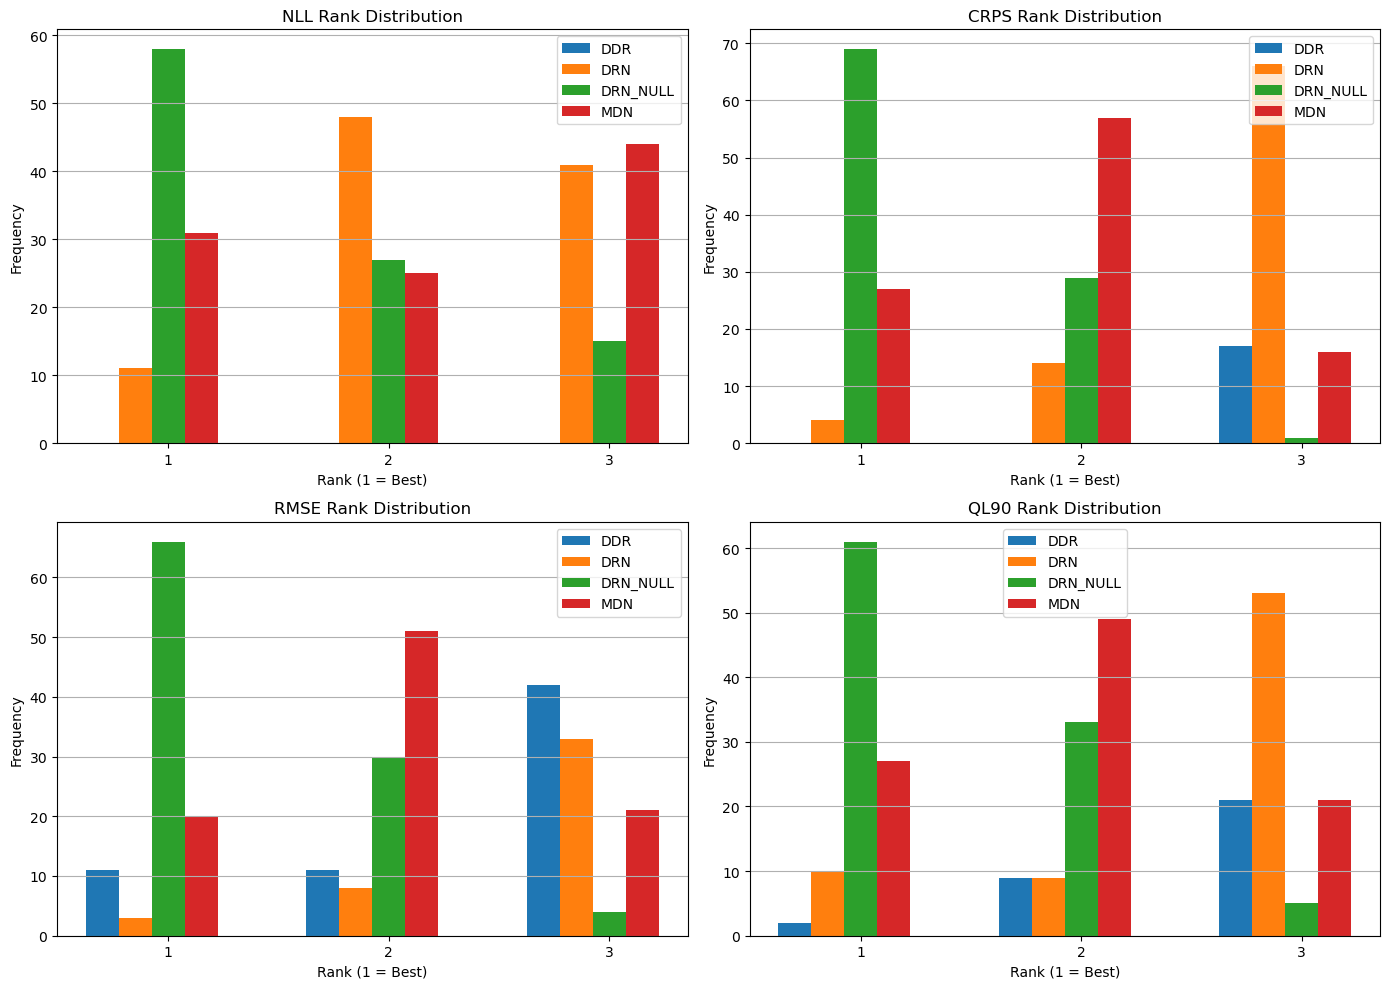

In [11]:
# Plotting side-by-side histograms at each x-tick (bar plot style)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

rank_bins = [1, 2, 3]  # 4, 5]
bar_width = 0.15
model_list = list(ranks_nll.columns)
x = np.arange(len(rank_bins))

for ax, (metric, rank_df) in zip(axes, metric_ranks.items()):
    for i, model in enumerate(model_list):
        counts = (
            rank_df[model].value_counts().reindex(rank_bins, fill_value=0).sort_index()
        )
        ax.bar(x + i * bar_width, counts.values, width=bar_width, label=model)

    ax.set_title(f"{metric} Rank Distribution")
    ax.set_xlabel("Rank (1 = Best)")
    ax.set_ylabel("Frequency")
    ax.set_xticks(x + bar_width * 2)
    ax.set_xticklabels(rank_bins)
    ax.legend()
    ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig(PLOT_DIR / "rank_distributions.png")

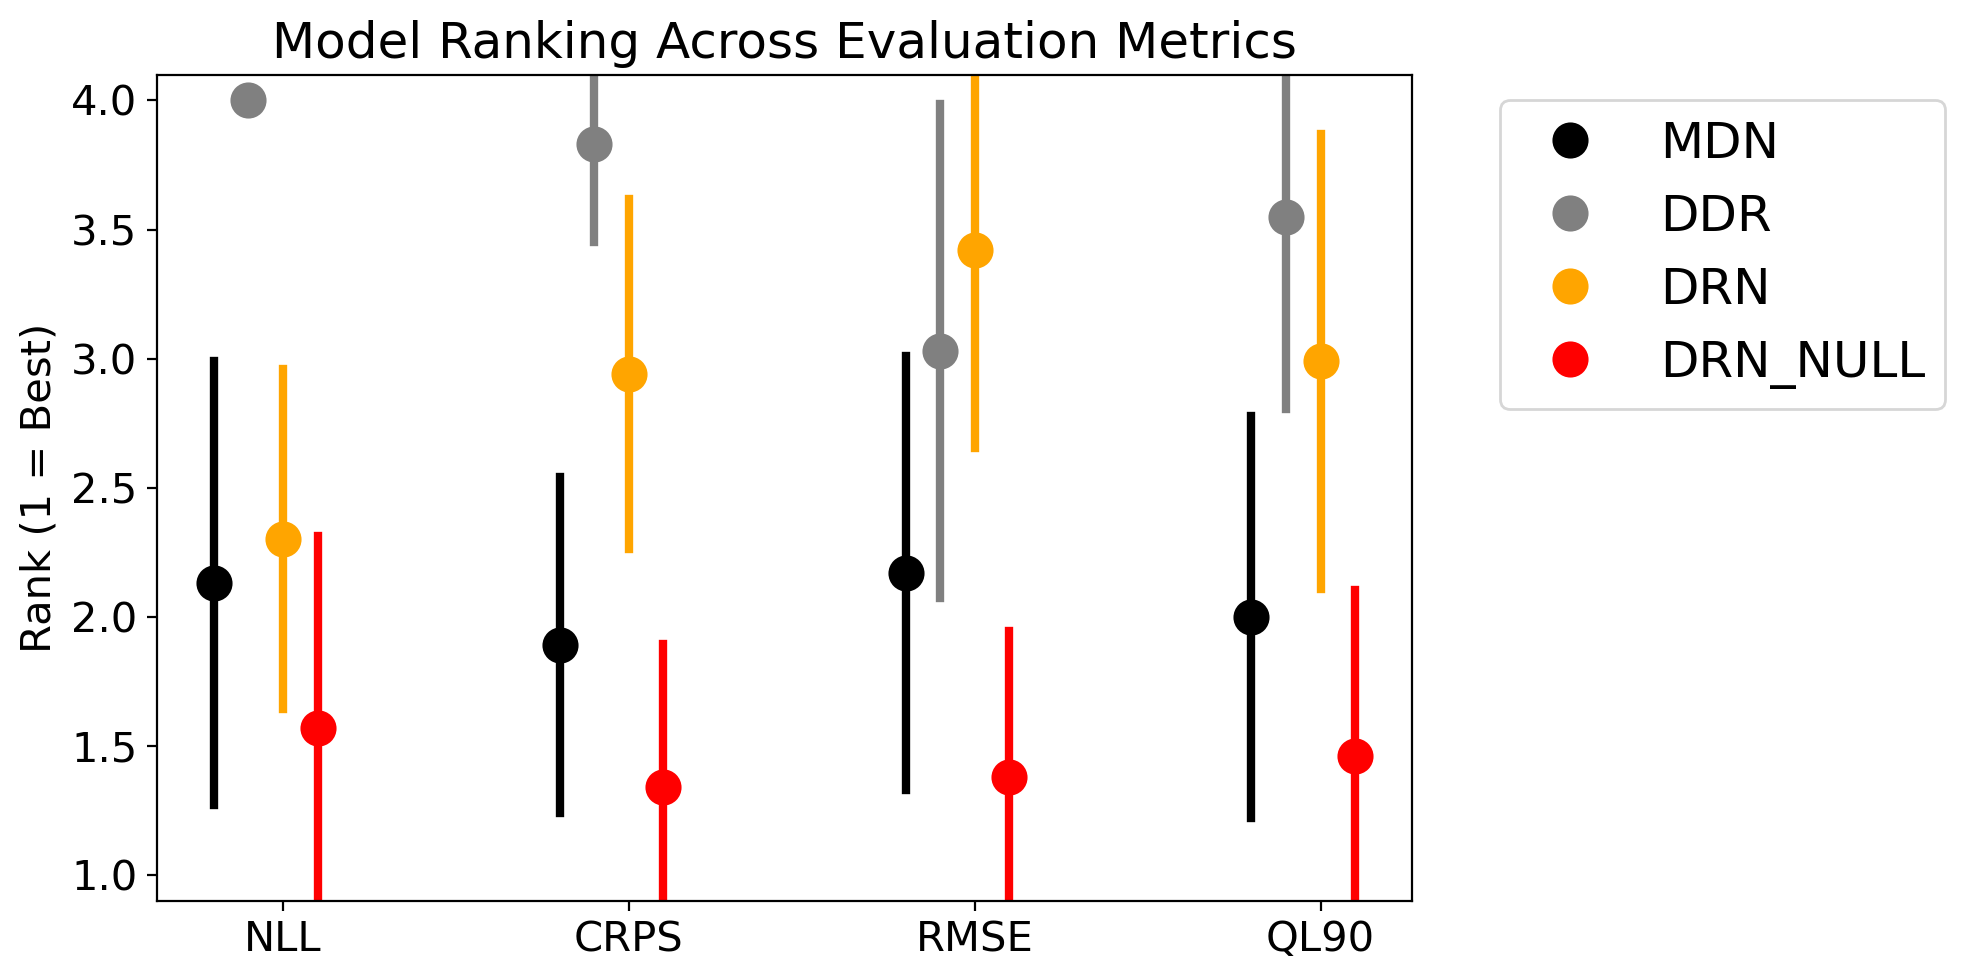

In [12]:
# Collect stats for all metrics
summary_stats = []

for metric_name, df in metric_ranks.items():
    for model in df.columns:
        summary_stats.append(
            {
                "Metric": metric_name,
                "Model": model,
                "Mean": df[model].mean(),
                "Std": df[model].std(),
            }
        )

summary_df = pd.DataFrame(summary_stats)

# Unique models and metrics for plotting
models = [
    # "CANN_GLM",
    # "CANN_CONSTANT",
    "MDN",
    "DDR",
    "DRN",
    "DRN_NULL",
]  ##summary_df["Model"].unique()
metrics = summary_df["Metric"].unique()
colors = dict(zip(models, sns.color_palette(n_colors=len(models))))

# Manually assign colors to each model
colors = {
    "DRN_NULL": "red",
    "DRN": "orange",
    # "CANN_CONSTANT": "blue",
    # "CANN_GLM": "teal",
    "MDN": "black",
    "DDR": "gray",
}

# Regenerate the plot with larger title and legend font sizes
plt.figure(figsize=(10, 5), dpi=200)  # High resolution

offset = 0.1  # horizontal spacing between model points
for i, metric in enumerate(metrics):
    for j, model in enumerate(models):
        row = summary_df[
            (summary_df["Metric"] == metric) & (summary_df["Model"] == model)
        ].iloc[0]
        x = i + (j - len(models) / 2) * offset
        color = colors[model]
        plt.plot(
            [x, x],
            [row["Mean"] - row["Std"], row["Mean"] + row["Std"]],
            color=color,
            linewidth=3,
        )
        plt.plot(x, row["Mean"], "o", color=color, label=model, markersize=12)

# Deduplicate legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(
    by_label.values(),
    by_label.keys(),
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=18,
)

plt.xticks(ticks=range(len(metrics)), labels=metrics, fontsize=15)
plt.yticks(fontsize=15)
plt.title("Model Ranking Across Evaluation Metrics", fontsize=18)
plt.ylabel("Rank (1 = Best)", fontsize=15)
plt.ylim(0.9, 4.1)
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_ranking_summary.png")